In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score)
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('C:/Users/viryu/Downloads/Top Mentors/Gen AI Session 1/Assignment/4. Logistic Regresssion/bank-full.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [6]:
print("Shape:", df.shape)     
print(df.head())              
print(df.dtypes)              
print(df.isnull().sum())      
print(df['y'].value_counts())

Shape: (45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
age           int64
job          object
marital      object
education    object
default     

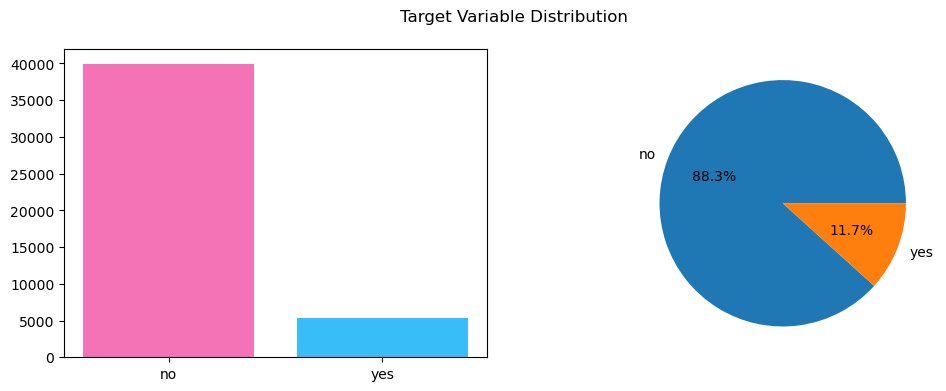

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = df['y'].value_counts()
axes[0].bar(vc.index, vc.values, color=['#f472b6','#38bdf8'])
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%')
plt.suptitle('Target Variable Distribution')
plt.show()

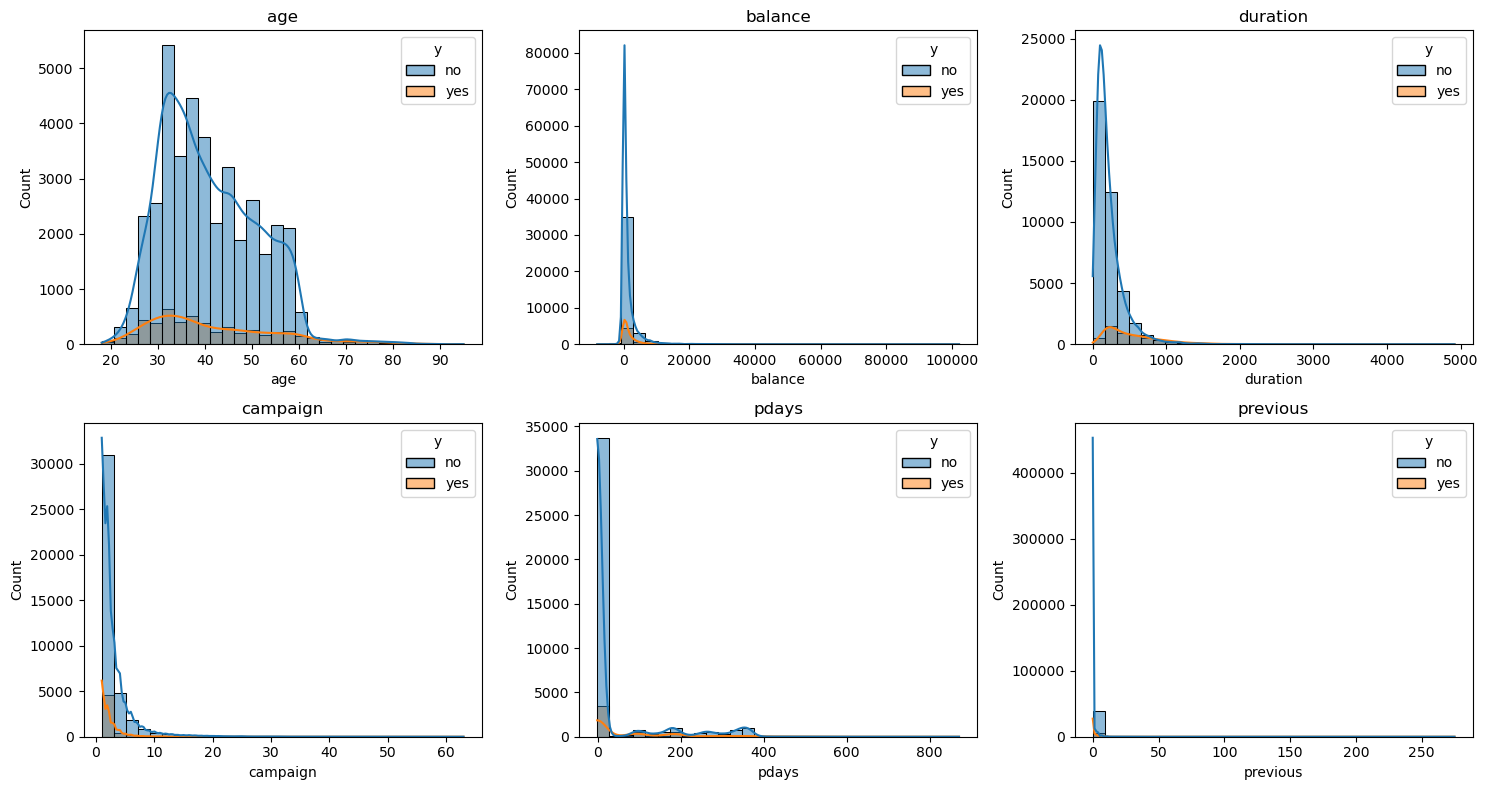

In [8]:
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='y', bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout(); plt.show()

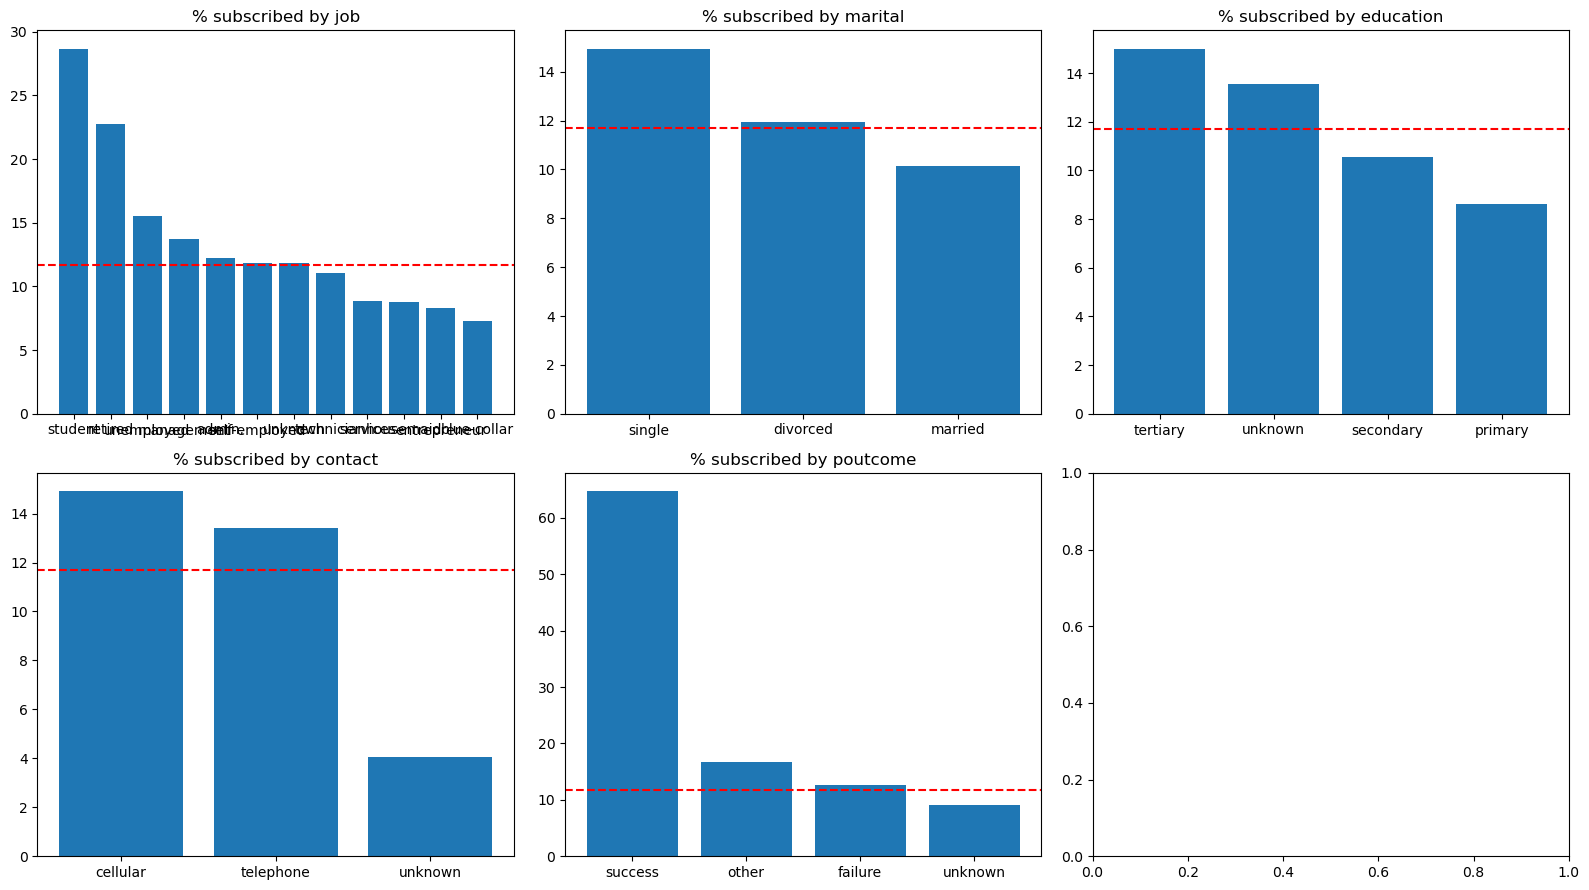

In [9]:
cat_cols = ['job', 'marital', 'education', 'contact', 'poutcome']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    rates = df.groupby(col)['y'].apply(lambda x: (x=='yes').mean()*100)
    rates = rates.sort_values(ascending=False)
    axes[i].bar(rates.index, rates.values)
    axes[i].axhline(y=(df['y']=='yes').mean()*100, color='red', ls='--')
    axes[i].set_title(f'% subscribed by {col}')
plt.tight_layout(); plt.show()

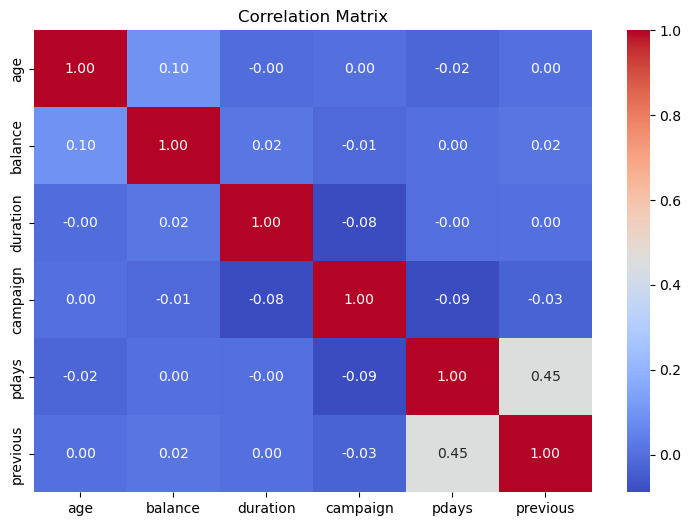

In [10]:
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')
plt.show()

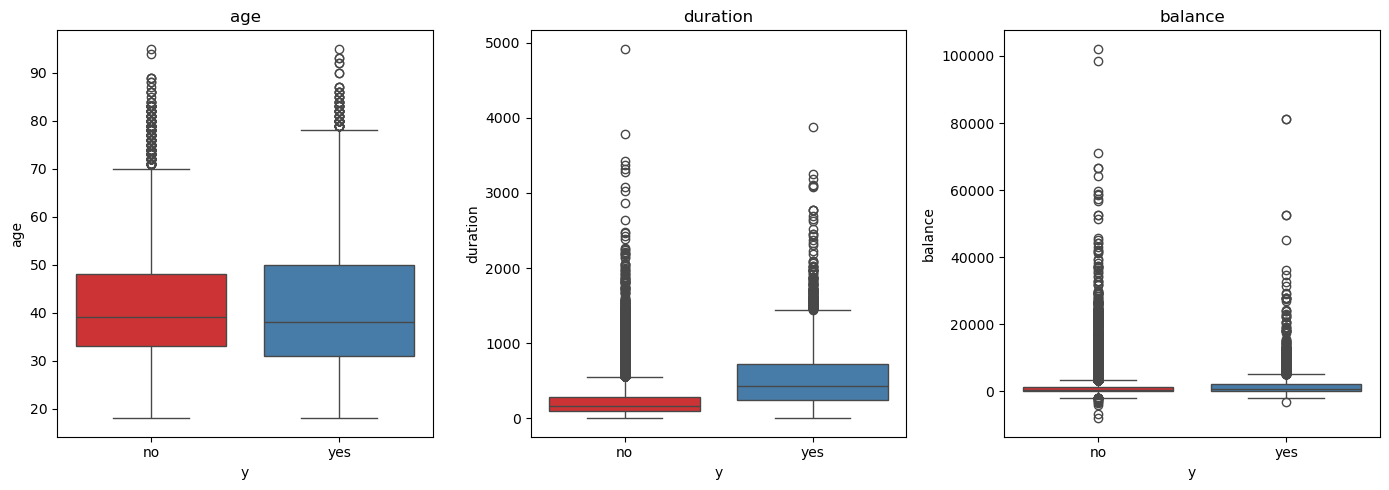

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ['age', 'duration', 'balance']):
    sns.boxplot(data=df, x='y', y=col, ax=ax, palette = 'Set1')
    ax.set_title(col)
plt.tight_layout(); plt.show()

In [18]:
df2 = df.copy()
df2['y'] = (df2['y'] == 'yes').astype(int)

le = LabelEncoder()
cat_feats = df2.select_dtypes(include='object').columns.tolist()
for col in cat_feats:
    df2[col] = le.fit_transform(df2[col])

print("Categorical columns encoded:", cat_feats)
df2.head(3)

Categorical columns encoded: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0


In [19]:
df_maj = df2[df2['y'] == 0] 
df_min = df2[df2['y'] == 1]  


df_min_up = resample(df_min,
                     replace=True,       
                     n_samples=len(df_maj),  
                     random_state=42)

df_bal = pd.concat([df_maj, df_min_up])
print("Before:", df_maj.shape[0], "no  |", df_min.shape[0], "yes")
print("After :", df_bal['y'].value_counts().to_dict())

Before: 39922 no  | 5289 yes
After : {0: 39922, 1: 39922}


In [21]:
X = df_bal.drop('y', axis=1)   
y = df_bal['y']               

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y )       
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (63875, 16)  |  Test: (15969, 16)


In [22]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)                          
    y_pred = model.predict(X_test)                       
    y_prob = model.predict_proba(X_test)[:, 1]          
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cr   = classification_report(y_test, y_pred, target_names=['No','Yes'])
    cm   = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    results[name] = dict(acc=acc, auc=auc, cr=cr, cm=cm, fpr=fpr, tpr=tpr)
    print(f"{name}: Accuracy={acc:.4f}  AUC={auc:.4f}")

Logistic Regression: Accuracy=0.7978  AUC=0.8710
Random Forest: Accuracy=0.9707  AUC=0.9998
Gradient Boosting: Accuracy=0.8616  AUC=0.9288


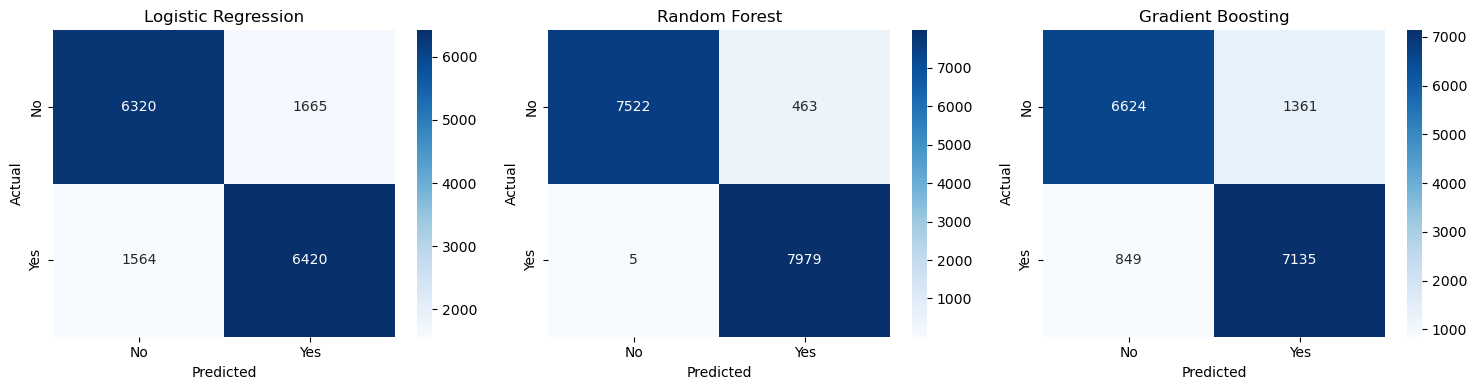

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

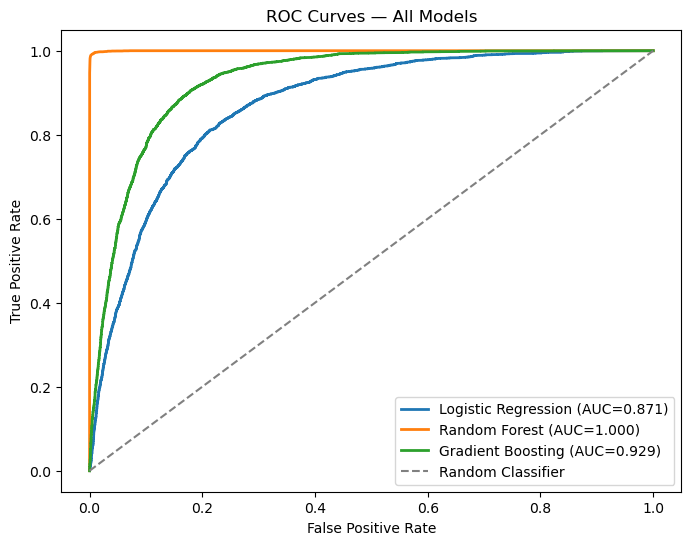

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, r in results.items():
    ax.plot(r['fpr'], r['tpr'], lw=2, label=f"{name} (AUC={r['auc']:.3f})")
ax.plot([0,1],[0,1],'--', color='grey', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(); plt.show()

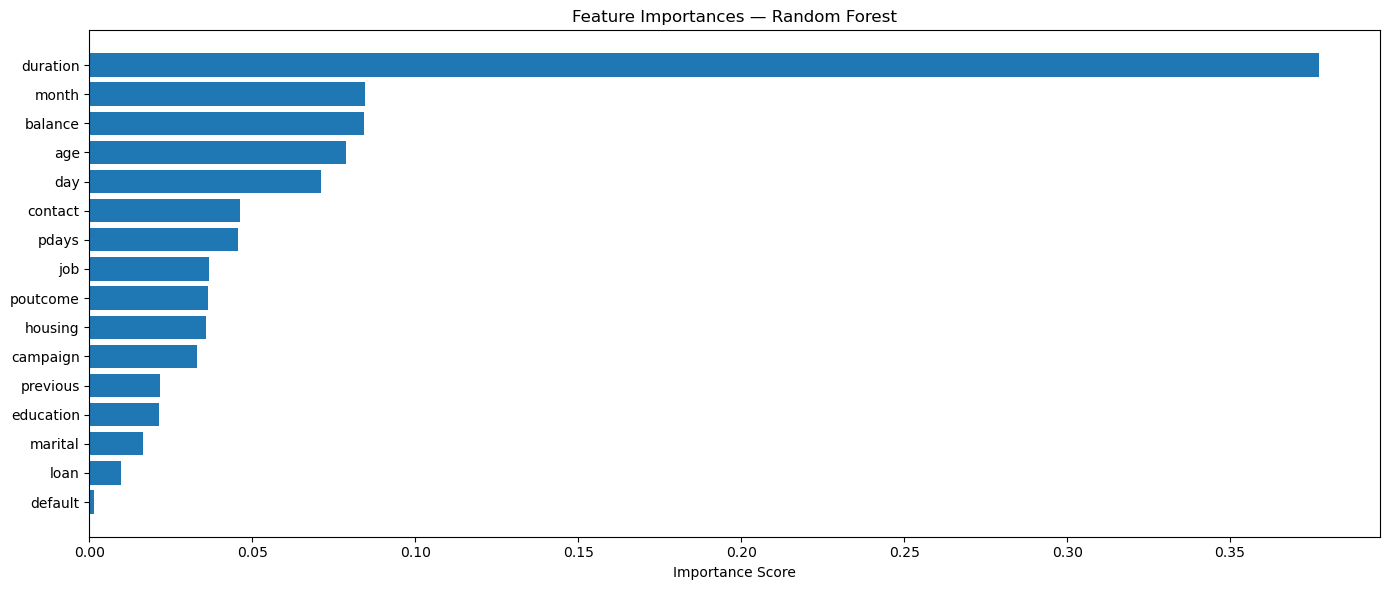

In [33]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(importances.index, importances.values)
ax.set_title('Feature Importances — Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.show()

# Bank Term Deposit — Key Insights

* Customers who had a positive response in previous campaigns are more likely to subscribe again.

* Call duration plays an important role — longer calls usually lead to higher chances of subscription.

* Too many repeated contacts can reduce customer interest and lower success rates.

* Customers with higher balance show slightly higher chances of investing.

* The model performs well in identifying customers who will not subscribe, but predicting subscribers is slightly harder.

* Overall, customer engagement and past interaction are the most important factors in predicting term deposit subscriptions.
